Импортируем все библиотеки

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import kruskal

import matplotlib.pyplot as plt
import seaborn as sns

Начинаем чистку датасета, вспомогательные функции

In [2]:
def normalize_id(series: pd.Series, allowed_lengths=(10, 12)) -> pd.Series:
    """
    Нормализует ИНН/ОГРН:
    - переводит в строку
    - убирает .0
    - оставляет только цифры
    - оставляет только значения допустимой длины
    """
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.where(s.str.len().isin(allowed_lengths))
    return s


def normalize_text(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.lower().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    return s


def to_binary(series: pd.Series) -> pd.Series:
    """
    Приводит признак к 0/1.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(int)

    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).clip(lower=0, upper=1).astype(int)

    s = series.astype("string").str.lower().str.strip()

    true_values = {"1", "true", "yes", "да", "y", "имеется", "актуален"}
    false_values = {"0", "false", "no", "нет", "n", "не имеется"}

    out = pd.Series(np.nan, index=series.index, dtype="float")
    out[s.isin(true_values)] = 1
    out[s.isin(false_values)] = 0

    return out.fillna(0).astype(int)


def mode_or_first(series: pd.Series):
    """
    Берет самое частое название владельца среди всех товарных знаков компании.
    """
    s = series.dropna()
    if s.empty:
        return None
    mode = s.mode()
    if not mode.empty:
        return mode.iloc[0]
    return s.iloc[0]

Чтение и очистка данных роспатента

In [3]:
df = pd.read_csv("data-rospatent.csv", sep=",", low_memory=False)
print(df.shape)
df.head(3)

(1102388, 58)


,registration number,registration date,application number,application date,priority date,exhibition priority date,paris convention priority number,paris convention priority date,paris convention priority country code,initial application number,...,color,color trademark specification,light,light specification,changing,changing specification,positional,positional specification,actual,publication URL
0,﻿80,19361027.0,187,19360815.0,19360815.0,NaN,NaN,NaN,US,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,http://www1.fips.ru/fips_servl/fips_servlet?DB...
1,82,19361027.0,112,19360814.0,19360814.0,NaN,NaN,19231031.0,GB,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,True,http://www1.fips.ru/fips_servl/fips_servlet?DB...
2,83,19361027.0,110,19360804.0,19360804.0,NaN,NaN,19231031.0,GB,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,True,http://www1.fips.ru/fips_servl/fips_servlet?DB...


In [4]:
cols = [
    "registration number",
    "application number",
    "registration date",
    "application date",
    "expiration date",
    "right holder name",
    "right holder inn",
    "right holder ogrn",
    "kind specification",
    "actual",
    "color",
    "color specification",
    "unprotected elements",
    "threedimensional",
    "sound",
    "light",
    "positional",
    "changing",
    "publication URL",
]

df = df[cols].copy()

df.columns = [
    "reg_number",
    "app_number",
    "reg_date",
    "app_date",
    "expire_date",
    "owner",
    "inn",
    "ogrn",
    "kind",
    "actual",
    "color",
    "color_spec",
    "unprotect_elem",
    "three_d",
    "sound",
    "light",
    "positional",
    "changing",
    "url",
]

In [5]:
# даты
for col in ["reg_date", "app_date", "expire_date"]:
    df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")

# текстовые поля
df["owner"] = normalize_text(df["owner"])
df["kind"] = normalize_text(df["kind"])
df["country"] = df["country"].astype("string").str.strip().str.upper()

# идентификаторы
df["inn"] = normalize_id(df["inn"], allowed_lengths=(10, 12))
df["ogrn"] = normalize_id(df["ogrn"], allowed_lengths=(13, 15))

# бинарные поля
binary_cols = ["actual", "color", "three_d", "sound", "light", "positional", "changing"]
for col in binary_cols:
    df[col] = to_binary(df[col])

# убираем строки без владельца, без даты регистрации, без номера регистрации
df = df.dropna(subset=["owner", "reg_date", "reg_number"]).copy()

# убираем дубликаты знаков
df = df.drop_duplicates(subset=["reg_number"]).copy()

# возраст товарного знака
today = pd.Timestamp.today().normalize()
df["age_years"] = (today - df["reg_date"]).dt.days / 365.25
df["age_years"] = df["age_years"].clip(lower=0)

df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1101480 entries, 0 to 1102387
Data columns (total 21 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   reg_number      1101480 non-null  object        
 1   app_number      1101272 non-null  object        
 2   reg_date        1101480 non-null  datetime64[ns]
 3   app_date        1101166 non-null  datetime64[ns]
 4   expire_date     1101471 non-null  datetime64[ns]
 5   owner           1101480 non-null  string        
 6   inn             407210 non-null   string        
 7   ogrn            553296 non-null   string        
 8   country         1101417 non-null  string        
 9   kind            29 non-null       string        
 10  actual          1101480 non-null  int64         
 11  color           1101480 non-null  int64         
 12  color_spec      413404 non-null   object        
 13  unprotect_elem  197186 non-null   object        
 14  three_d         1101480

reg_number              0
app_number            208
reg_date                0
app_date              314
expire_date             9
owner                   0
inn                694270
ogrn               548184
country                63
kind              1101451
actual                  0
color                   0
color_spec         688076
unprotect_elem     904294
three_d                 0
sound                   0
light                   0
positional              0
changing                0
url                     0
age_years               0
dtype: int64

Исходный датасет Роспатента содержит 1 101 480 записей о зарегистрированных товарных знаках и включает 21 переменную, описывающую характеристики знаков и сведения о правообладателях. Каждая строка датасета соответствует одному товарному знаку.

Ключевые поля, такие как номер регистрации, дата регистрации и наименование правообладателя, практически не содержат пропусков, что позволяет использовать данные для последующего анализа без значительных потерь наблюдений. Аналогично, бинарные признаки, характеризующие тип товарного знака (цветной, трёхмерный, звуковой и др.), заполнены полностью.

Наиболее значительные пропуски наблюдаются в идентификационных переменных правообладателей. В частности, идентификатор ИНН присутствует лишь у 407 тыс. записей, что связано с тем, что значительная часть правообладателей является иностранными компаниями или физическими лицами. В связи с этим экономический анализ компаний может быть проведён только для подвыборки наблюдений, содержащих корректные идентификаторы организаций.

Некоторые текстовые переменные, такие как описание цветов или неохраняемых элементов, также имеют значительное количество пропусков. Это связано со спецификой регистрации товарных знаков, поскольку такие характеристики используются лишь в отдельных случаях.

Таблица компаний: одна строка = одна компания

In [6]:
# для экономики нужны компании с валидным ИНН
df_econ = df.dropna(subset=["inn"]).copy()

company_df = (
    df_econ
    .groupby("inn", as_index=False)
    .agg(
        owner=("owner", mode_or_first),
        num_marks=("reg_number", "count"),
        num_active=("actual", "sum"),
        avg_age=("age_years", "mean"),
        active_share=("actual", "mean"),
        has_color=("color", "max"),
        has_3d=("three_d", "max"),
        has_sound=("sound", "max"),
        has_light=("light", "max"),
        has_positional=("positional", "max"),
        has_changing=("changing", "max"),
        first_reg_date=("reg_date", "min"),
        last_reg_date=("reg_date", "max"),
    )
)

company_df.head()
company_df["num_marks"].describe()

count    223950.000000
mean          1.818308
std           6.395541
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        1203.000000
Name: num_marks, dtype: float64

После агрегирования данных по правообладателям была сформирована таблица компаний, содержащая 223 950 наблюдений. Каждая строка таблицы соответствует одной компании и описывает характеристики её портфеля товарных знаков.

Анализ распределения количества товарных знаков показывает крайне неравномерную структуру рынка. Медианное значение числа товарных знаков равно 1, при этом 75% компаний имеют лишь один зарегистрированный знак. Это свидетельствует о том, что для большинства компаний регистрация товарного знака носит единичный характер и используется преимущественно для защиты основного бренда.

В то же время в выборке присутствует небольшая группа компаний с крупными портфелями товарных знаков. Максимальное значение достигает 1203 зарегистрированных знаков. Наличие таких экстремальных значений приводит к сильной асимметрии распределения: среднее значение числа товарных знаков (1.82) существенно превышает медиану.

Полученные результаты свидетельствуют о высокой концентрации прав на товарные знаки. Подавляющее большинство компаний ограничивается регистрацией одного знака, тогда как системная портфельная стратегия брендинга характерна лишь для небольшой группы правообладателей.

In [7]:
# регистрации за последние 3 года до 2024-01-01
df_before_2024 = df_econ[df_econ["reg_date"] < "2024-01-01"].copy()

recent_marks = df_before_2024[
    df_before_2024["reg_date"] >= "2021-01-01"
]

marks_last_3y = (
    recent_marks
    .groupby("inn")
    .size()
    .rename("marks_last_3y")
    .reset_index()
)

company_df = company_df.merge(marks_last_3y, on="inn", how="left")
company_df["marks_last_3y"] = company_df["marks_last_3y"].fillna(0).astype(int)

company_df["new_share"] = company_df["marks_last_3y"] / company_df["num_marks"]
company_df["new_share"] = company_df["new_share"].fillna(0)

In [8]:
# "сложность" бренда
complexity_cols = ["has_color", "has_3d", "has_sound", "has_light", "has_positional", "has_changing"]
company_df["brand_complexity"] = company_df[complexity_cols].sum(axis=1)

company_df.head()

,inn,owner,num_marks,num_active,avg_age,active_share,has_color,has_3d,has_sound,has_light,has_positional,has_changing,first_reg_date,last_reg_date,marks_last_3y,new_share,brand_complexity
0,0000000000,омар мохаммад касем,8,8,3.527721,1.0,0,0,0,0,0,0,2021-01-27,2024-04-04,6,0.75,0
1,000000000000,галузин евгений николаевич,2,2,2.433949,1.0,0,0,0,0,0,0,2023-06-09,2024-02-26,1,0.50,0
2,000610050300,кабжанова жанна сергалиевна,1,1,3.603012,1.0,0,0,0,0,0,0,2022-08-17,2022-08-17,1,1.00,0
3,0100000533,"общество с ограниченной ответственностью ""витязь""",1,1,1.702943,1.0,0,0,0,0,0,0,2024-07-11,2024-07-11,0,0.00,0
4,0100001103,"общество с ограниченной ответственностью ""инте...",1,1,1.609856,1.0,0,0,0,0,0,0,2024-08-14,2024-08-14,0,0.00,0


Быстрые проверки

In [9]:
# топ компаний по числу ТЗ
company_df.sort_values("num_marks", ascending=False).head(10)

,inn,owner,num_marks,num_active,avg_age,active_share,has_color,has_3d,has_sound,has_light,has_positional,has_changing,first_reg_date,last_reg_date,marks_last_3y,new_share,brand_complexity
187882,7736207543,общество с ограниченной ответственностью «яндекс»,1203,1199,2.871837,0.996675,0,1,0,0,1,1,2008-08-11,2025-10-17,483,0.401496,3
104634,5504036333,"публичное акционерное общество ""газпром нефть""",709,703,4.023679,0.991537,0,1,0,0,1,1,2016-10-12,2025-10-23,289,0.407616,3
52405,3328426780,закрытое акционерное общество «стародворские к...,583,579,3.849244,0.993139,0,0,0,0,0,0,2008-02-07,2025-10-23,362,0.620926,0
52404,3328426765,закрытое акционерное общество «мясная галерея»,554,554,3.631388,1.000000,0,1,0,0,0,0,2006-03-14,2025-10-09,342,0.617329,1
177873,7728029110,"акционерное общество ""торговый дом ""перекресток""",497,496,4.148477,0.997988,0,0,0,0,0,0,2002-05-18,2025-10-16,284,0.571429,0
154273,7707083893,"публичное акционерное общество ""сбербанк россии""",476,476,4.044674,1.000000,0,0,0,0,0,0,2018-12-12,2025-10-20,261,0.548319,0
205874,7825706086,"общество с ограниченной ответственностью ""агро...",465,465,3.657392,1.000000,0,0,1,0,0,0,2019-01-23,2025-10-16,301,0.647312,1
188835,7740000076,публичное акционерное общество «мобильные теле...,436,436,3.329591,1.000000,0,1,0,0,1,1,1997-08-27,2025-10-24,212,0.486239,3
153224,7705183476,общество с ограниченной ответственностью «арне...,430,430,12.786190,1.000000,0,1,0,0,0,0,1969-03-31,2025-10-09,31,0.072093,1
80689,5020037784,"акционерное общество ""аб инбев эфес""",421,345,12.434824,0.819477,0,1,0,0,0,0,1994-10-06,2025-10-29,60,0.142518,1


Анализ крупнейших правообладателей показывает, что значительные портфели товарных знаков сосредоточены у ограниченного числа компаний. Лидером по количеству зарегистрированных знаков является компания «Яндекс», в портфеле которой насчитывается 1203 товарных знака.

К числу крупнейших правообладателей также относятся такие компании, как «Газпром нефть», «Сбербанк России», «МТС» и торговая сеть «Перекрёсток». Помимо крупных технологических и финансовых компаний, в список также входят производители потребительских товаров и продуктов питания, например «Стародворские колбасы» и «AB InBev Efes».

Для большинства крупнейших правообладателей характерна высокая доля действующих товарных знаков: в большинстве случаев более 99% зарегистрированных знаков остаются активными. Это свидетельствует о системном управлении портфелем брендов и активном использовании зарегистрированных обозначений.

Кроме того, значительная часть портфеля крупнейших компаний была зарегистрирована в последние годы. Например, у компании «Яндекс» около 40% товарных знаков зарегистрировано за последние три года. Это указывает на продолжающееся расширение и обновление бренд-портфелей.

Таким образом, крупнейшие портфели товарных знаков принадлежат крупным компаниям, активно использующим брендинг как инструмент развития бизнеса и защиты нематериальных активов.

In [10]:
# связь: возраст -> активность
company_df[["avg_age", "active_share"]].corr()

,avg_age,active_share
avg_age,1.000000,-0.066258
active_share,-0.066258,1.000000


Для проверки связи между возрастом портфеля товарных знаков и долей действующих регистраций была рассчитана корреляция между показателями среднего возраста портфеля и доли активных знаков. Полученное значение коэффициента корреляции составило −0.066, что свидетельствует о крайне слабой отрицательной связи между этими переменными.

Таким образом, возраст портфеля товарных знаков практически не связан с долей действующих регистраций. Это означает, что компании могут поддерживать активность своих брендов независимо от их возраста. Старые товарные знаки нередко продолжают активно использоваться, тогда как часть более новых регистраций может со временем утрачивать актуальность.

Полученный результат подтверждает, что структура портфеля товарных знаков формируется под влиянием множества факторов и не может быть объяснена исключительно временем существования бренда.

In [11]:
# кто чаще использует цветные знаки
company_df.groupby("has_color")["num_marks"].mean()

has_color
0     1.815576
1    25.346154
Name: num_marks, dtype: float64

Дополнительно была изучена связь между размером портфеля товарных знаков и использованием более сложных форм брендинга. В частности, был рассмотрен признак наличия цветных товарных знаков.

Результаты показали значительные различия между компаниями, использующими цветные знаки, и компаниями, не использующими их. Среднее число товарных знаков у компаний без цветных регистраций составляет около 1.8, тогда как у компаний, имеющих хотя бы один цветной знак, этот показатель превышает 25.

Таким образом, компании, использующие цветные товарные знаки, обладают в среднем более чем в десять раз более крупным портфелем брендов. Это свидетельствует о том, что использование сложных типов товарных знаков характерно прежде всего для компаний с развитой стратегией управления брендом.

Полученный результат согласуется с экономической логикой: регистрация цветных обозначений требует более продуманной бренд-стратегии и чаще используется крупными компаниями, активно развивающими свои бренды.

Индекс силы бренда

In [12]:
def pct_rank(series: pd.Series) -> pd.Series:
    return series.rank(pct=True, method="average")

company_df["brand_score"] = (
    0.35 * pct_rank(company_df["num_marks"]) +
    0.25 * company_df["active_share"] +
    0.20 * pct_rank(company_df["avg_age"]) +
    0.10 * pct_rank(company_df["marks_last_3y"]) +
    0.10 * (
        company_df["brand_complexity"] / company_df["brand_complexity"].max()
        if company_df["brand_complexity"].max() > 0 else 0
    )
)

company_df["brand_score"].describe()

count    223950.000000
mean          0.574386
std           0.113784
min           0.192635
25%           0.469638
50%           0.578540
75%           0.610778
max           0.964544
Name: brand_score, dtype: float64

In [13]:
company_df.sort_values("brand_score", ascending=False)[
    ["owner", "brand_score", "num_marks", "active_share", "brand_complexity"]
].head(10)

,owner,brand_score,num_marks,active_share,brand_complexity
150866,"общество с ограниченной ответственностью ""глав...",0.964544,59,1.000000,2
181936,общество с ограниченной ответственностью «алвиса»,0.953785,100,0.990000,2
104634,"публичное акционерное общество ""газпром нефть""",0.936043,709,0.991537,3
73197,"общество с ограниченной ответственностью ""орими""",0.932430,158,1.000000,2
153224,общество с ограниченной ответственностью «арне...,0.932003,430,1.000000,1
191674,"общество с ограниченной ответственностью ""орлов""",0.931291,134,1.000000,1
89827,"акционерное общество ""отисифарм""",0.931175,264,1.000000,1
191820,"общество с ограниченной ответственностью ""пирс""",0.930943,28,1.000000,2
105282,"общество с ограниченной ответственностью ""алко...",0.928486,31,1.000000,1
199785,"акционерное общество ""невская косметика""",0.928015,36,1.000000,1


На основе характеристик портфеля товарных знаков был рассчитан интегральный индекс силы бренда. Индекс учитывает размер портфеля, долю действующих знаков, возраст бренда, активность регистрации новых знаков и сложность используемых типов товарных знаков.

Распределение индекса показывает, что большинство компаний имеют умеренные значения показателя. Медианное значение индекса составляет 0.58, а верхний квартиль — около 0.61. Это означает, что лишь около четверти компаний демонстрируют относительно высокий уровень развития бренд-портфеля.

Максимальные значения индекса достигают примерно 0.96 и характерны для компаний, активно управляющих своими брендами. В число лидеров входят крупные производители потребительских товаров и компании с развитой продуктовой линейкой, такие как «Газпром нефть», «Orimi», «Невская косметика» и другие.

Анализ характеристик лидирующих компаний показывает, что высокий индекс силы бренда достигается не только за счёт большого количества товарных знаков, но и благодаря высокой доле действующих регистраций и использованию различных типов товарных знаков. Это свидетельствует о системном подходе к управлению нематериальными активами и активной бренд-стратегии.

Кластеризация

In [14]:
cluster_features = [
    "num_marks",
    "num_active",
    "avg_age",
    "active_share",
    "brand_complexity",
]

In [15]:
# убираем экстремальный выброс по числу знаков
thr = company_df["num_marks"].quantile(0.999)

df_main = company_df[company_df["num_marks"] <= thr].copy()
df_out = company_df[company_df["num_marks"] > thr].copy()

df_out.shape

(217, 18)

In [16]:
X = df_main[cluster_features].copy()
X["num_marks"] = np.log1p(X["num_marks"])
X["num_active"] = np.log1p(X["num_active"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_main["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    df_main
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile

,num_marks,num_active,avg_age,active_share,brand_complexity
cluster,,,,,
0,6.03,6.02,3.68,1.00,0.00
1,1.15,1.15,3.20,1.00,0.00
2,13.15,13.06,4.57,0.98,1.02


РСА для визуализации

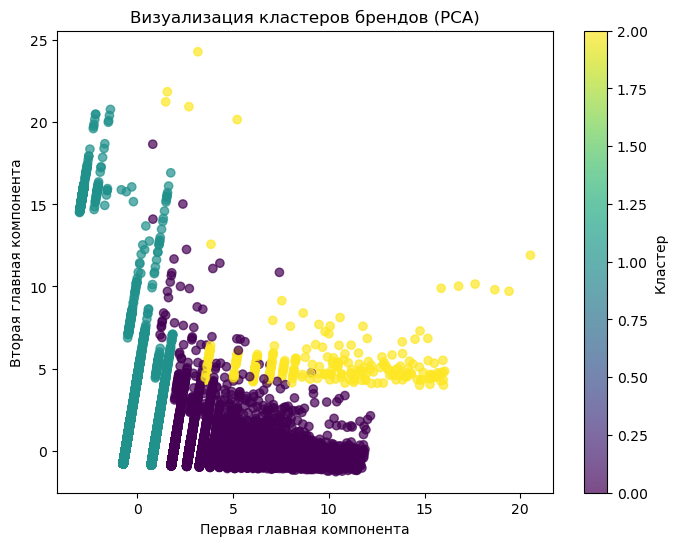

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_main["pca_x"] = X_pca[:, 0]
df_main["pca_y"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df_main["pca_x"],
    df_main["pca_y"],
    c=df_main["cluster"],
    alpha=0.7
)
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Визуализация кластеров брендов (PCA)")
plt.colorbar(label="Кластер")
plt.show()

Возвращаем выбросы как cluster = -1

In [18]:
df_out["cluster"] = -1
df_out["pca_x"] = np.nan
df_out["pca_y"] = np.nan

df_ml = pd.concat([df_main, df_out], ignore_index=True)

df_ml["cluster"].value_counts()

cluster
 1    199864
 0     23575
 2       294
-1       217
Name: count, dtype: int64

In [19]:
df_ml.groupby("cluster")[cluster_features + ["brand_score"]].mean().round(2)

,num_marks,num_active,avg_age,active_share,brand_complexity,brand_score
cluster,,,,,,
-1,140.98,140.32,4.33,1.00,0.27,0.84
0,6.03,6.02,3.68,1.00,0.00,0.77
1,1.15,1.15,3.20,1.00,0.00,0.55
2,13.15,13.06,4.57,0.98,1.02,0.79


Для выявления различных стратегий управления товарными знаками была проведена кластеризация компаний методом k-means. В качестве признаков использовались количество товарных знаков, число действующих знаков, средний возраст портфеля, доля действующих знаков и показатель сложности бренда.

В результате были выделены три основных кластера компаний.

Первый кластер — компании с минимальным портфелем

Наиболее многочисленная группа включает около 200 тысяч компаний (около 89% выборки). Для этих компаний характерно наличие одного товарного знака, который почти всегда остаётся активным. Портфель таких компаний относительно молодой и не содержит сложных типов товарных знаков.

Это типичная стратегия малого бизнеса: регистрация одного бренда для защиты названия компании или основного продукта.

Второй кластер — компании со средним портфелем

Второй кластер включает около 23 тысяч компаний (примерно 10% выборки). В среднем такие компании имеют около шести товарных знаков. Почти все знаки остаются действующими, что свидетельствует о систематическом использовании зарегистрированных брендов.

Для компаний этого типа характерна более продвинутая стратегия брендинга: регистрация нескольких обозначений, защита различных вариантов бренда или продуктовых линий.

Третий кластер — компании с развитым портфелем

Третий кластер является самым малочисленным и включает лишь несколько сотен компаний. Средний размер портфеля в этой группе превышает 13 товарных знаков. Такие компании чаще используют более сложные типы товарных знаков и обладают более зрелыми брендами.

Это компании, активно управляющие своими нематериальными активами и использующие товарные знаки как инструмент развития бизнеса и продуктовой стратегии.

Визуализация кластеров

Для наглядного представления структуры кластеров была применена методика понижения размерности PCA. Визуализация показывает, что выделенные группы компаний формируют различимые области в пространстве признаков, что подтверждает корректность кластеризации и наличие различий между стратегиями управления товарными знаками.

Проверка устойчивости для 4 кластеров

In [20]:
X4 = df_main[cluster_features].copy()
X4["num_marks"] = np.log1p(X4["num_marks"])
X4["num_active"] = np.log1p(X4["num_active"])

scaler4 = StandardScaler()
X4_scaled = scaler4.fit_transform(X4)

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_main["cluster_4"] = kmeans_4.fit_predict(X4_scaled)

cluster_profile_4 = (
    df_main
    .groupby("cluster_4")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile_4

,num_marks,num_active,avg_age,active_share,brand_complexity
cluster_4,,,,,
0,6.03,6.02,3.68,1.00,0.00
1,1.15,1.15,3.19,1.00,0.00
2,1.54,0.26,6.14,0.10,0.00
3,13.15,13.06,4.57,0.98,1.02


In [21]:
cluster_sizes = df_main["cluster_4"].value_counts().sort_index()
cluster_sizes

cluster_4
0     23587
1    199238
2       614
3       294
Name: count, dtype: int64

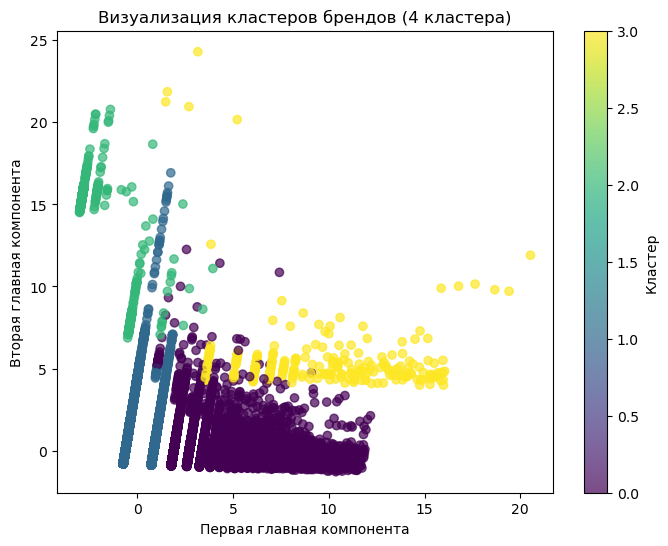

In [22]:
pca4 = PCA(n_components=2)
X4_pca = pca4.fit_transform(X4_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X4_pca[:, 0],
    X4_pca[:, 1],
    c=df_main["cluster_4"],
    alpha=0.7
)
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Визуализация кластеров брендов (4 кластера)")
plt.colorbar(label="Кластер")
plt.show()

Для проверки устойчивости результатов кластеризации была дополнительно рассмотрена модель с четырьмя кластерами. Полученные результаты показали, что основная структура сохраняется: по-прежнему выделяются компании с минимальным портфелем товарных знаков, компании со средним числом регистраций и небольшая группа компаний с развитой портфельной стратегией.

При этом при разбиении на четыре кластера дополнительно выделяется отдельная малочисленная группа компаний со старыми и преимущественно неактивными товарными знаками. Для этой группы характерно небольшое число регистраций, низкая доля действующих знаков и более высокий средний возраст портфеля.

Таким образом, результаты кластеризации можно считать устойчивыми: изменение числа кластеров не разрушает базовую типологию, а лишь уточняет её, выделяя внутри массовой группы дополнительный подтип компаний с неактивным портфелем товарных знаков.

Подготовка СПАРК

In [23]:
import pandas as pd

df_spark_1 = pd.read_excel("СПАРК_выборка_70-75.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_1.columns = df_spark_1.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_1.columns]
df_spark_1 = df_spark_1[keep_cols].copy()

df_spark_1 = df_spark_1.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_1 = df_spark_1.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_1, on="inn", how="inner")
df_merged.shape

(734, 41)

In [ ]:
df_spark_1 = pd.read_excel("СПАРК_выборка_70-75.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_2 = pd.read_excel("СПАРК_выборка_75-80.xlsx", header=3, dtype={"Код налогоплательщика": str})


In [24]:
import pandas as pd

df_spark_2 = pd.read_excel("СПАРК_выборка_75-80.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_2.columns = df_spark_2.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_2.columns]
df_spark_2 = df_spark_2[keep_cols].copy()

df_spark_2 = df_spark_2.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_2 = df_spark_2.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_2, on="inn", how="inner")
df_merged.shape

(663, 41)

In [25]:
import pandas as pd

df_spark_3 = pd.read_excel("СПАРК_выборка_80-85.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_3.columns = df_spark_3.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_3.columns]
df_spark_3 = df_spark_3[keep_cols].copy()

df_spark_3 = df_spark_3.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_3 = df_spark_3.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_3, on="inn", how="inner")
df_merged.shape

(684, 41)

In [26]:
import pandas as pd

df_spark_4 = pd.read_excel("СПАРК_выборка_85-90.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_4.columns = df_spark_4.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_4.columns]
df_spark_4 = df_spark_4[keep_cols].copy()

df_spark_4 = df_spark_4.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_4 = df_spark_4.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_4, on="inn", how="inner")
df_merged.shape

(683, 41)

In [27]:
import pandas as pd

df_spark_5 = pd.read_excel("СПАРК_выборка_90-100.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_5.columns = df_spark_5.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_5.columns]
df_spark_5 = df_spark_5[keep_cols].copy()

df_spark_5 = df_spark_5.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_5 = df_spark_5.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_5, on="inn", how="inner")
df_merged.shape

(820, 41)

In [28]:
import pandas as pd

df_spark_6 = pd.read_excel("СПАРК_выборка_100-110.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_6.columns = df_spark_6.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_6.columns]
df_spark_6 = df_spark_6[keep_cols].copy()

df_spark_6 = df_spark_6.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_6 = df_spark_6.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_6, on="inn", how="inner")
df_merged.shape

(822, 41)

In [29]:
import pandas as pd

df_spark_7 = pd.read_excel("СПАРК_выборка_110-120.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_7.columns = df_spark_7.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_7.columns]
df_spark_7 = df_spark_7[keep_cols].copy()

df_spark_7 = df_spark_7.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_7 = df_spark_7.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_7, on="inn", how="inner")
df_merged.shape

(828, 41)

In [30]:
import pandas as pd

df_spark_8 = pd.read_excel("СПАРК_выборка_120-130.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_8.columns = df_spark_8.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_8.columns]
df_spark_8 = df_spark_8[keep_cols].copy()

df_spark_8 = df_spark_8.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_8 = df_spark_8.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_8, on="inn", how="inner")
df_merged.shape

(799, 41)

In [31]:
import pandas as pd

df_spark_9 = pd.read_excel("СПАРК_выборка_130-140.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_9.columns = df_spark_9.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_9.columns]
df_spark_9 = df_spark_9[keep_cols].copy()

df_spark_9 = df_spark_9.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_9 = df_spark_9.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_9, on="inn", how="inner")
df_merged.shape

(892, 41)

In [32]:
import pandas as pd

df_spark_10 = pd.read_excel("СПАРК_выборка_140-150.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_10.columns = df_spark_10.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_10.columns]
df_spark_10 = df_spark_10[keep_cols].copy()

df_spark_10 = df_spark_10.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_10 = df_spark_10.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_10, on="inn", how="inner")
df_merged.shape

(805, 41)

In [33]:
import pandas as pd

df_spark_11 = pd.read_excel("СПАРК_выборка_150-165.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_11.columns = df_spark_11.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_11.columns]
df_spark_11 = df_spark_11[keep_cols].copy()

df_spark_11 = df_spark_11.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_11 = df_spark_11.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_11, on="inn", how="inner")
df_merged.shape

(926, 41)

In [34]:
import pandas as pd

df_spark_12 = pd.read_excel("СПАРК_выборка_165-180.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_12.columns = df_spark_12.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_12.columns]
df_spark_12 = df_spark_12[keep_cols].copy()

df_spark_12 = df_spark_12.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_12 = df_spark_12.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_12, on="inn", how="inner")
df_merged.shape

(933, 41)

In [35]:
import pandas as pd

df_spark_13 = pd.read_excel("СПАРК_выборка_180-195.xlsx", header=3, dtype={"Код налогоплательщика": str})
df_spark_13.columns = df_spark_13.columns.astype(str).str.replace("\n", " ").str.strip()
keep_cols = [
    "Код налогоплательщика",
    "Наименование",
    "Дата регистрации",
    "Возраст компании, лет",
    "Регион регистрации",
    "Вид деятельности/отрасль",
    "Организационно-правовая форма",
    "Размер компании",
    "2024, Среднесписочная численность работников",
    "2023, Выручка, тыс. RUB",
    "2024, Выручка, тыс. RUB",
    "2024, EBIT, тыс. RUB",
    "2024, Чистая прибыль (убыток), тыс. RUB",
    "2024, Активы  всего, тыс. RUB",
    "2024, Капитал и резервы, тыс. RUB",
    "2024, Собственный капитал, тыс. RUB",
    "2024, Совокупный долг, тыс. RUB",
    "2024, Заёмные средства (долгосрочные), тыс. RUB",
    "2024, Заёмные средства (краткосрочные), тыс. RUB",
    "2024, Долгосрочные обязательства, тыс. RUB",
    "2024, Краткосрочные обязательства, тыс. RUB",
]

keep_cols = [c for c in keep_cols if c in df_spark_13.columns]
df_spark_13 = df_spark_13[keep_cols].copy()

df_spark_13 = df_spark_13.rename(columns={
    "Код налогоплательщика": "inn",
    "Наименование": "company_name",
    "Дата регистрации": "company_reg_date",
    "Возраст компании, лет": "company_age_years",
    "Регион регистрации": "region",
    "Вид деятельности/отрасль": "industry",
    "Организационно-правовая форма": "opf",
    "Размер компании": "company_size",

    "2024, Среднесписочная численность работников": "employees_2024",

    "2023, Выручка, тыс. RUB": "revenue_2023",
    "2024, Выручка, тыс. RUB": "revenue_2024",
    "2024, EBIT, тыс. RUB": "ebit_2024",
    "2024, Чистая прибыль (убыток), тыс. RUB": "net_profit_2024",
    "2024, Активы  всего, тыс. RUB": "assets_2024",

    "2024, Капитал и резервы, тыс. RUB": "equity_reserves_2024",
    "2024, Собственный капитал, тыс. RUB": "equity_2024",
    "2024, Совокупный долг, тыс. RUB": "debt_total_2024",

    "2024, Заёмные средства (долгосрочные), тыс. RUB": "debt_long_2024",
    "2024, Заёмные средства (краткосрочные), тыс. RUB": "debt_short_2024",
    "2024, Долгосрочные обязательства, тыс. RUB": "liab_long_2024",
    "2024, Краткосрочные обязательства, тыс. RUB": "liab_short_2024",
})
df_spark_13 = df_spark_13.dropna(subset=["inn"])
df_merged = df_ml.merge(df_spark_13, on="inn", how="inner")
df_merged.shape

(909, 41)

In [36]:
df_spark_all = pd.concat(
    [
        df_spark_1, df_spark_2, df_spark_3, df_spark_4,
        df_spark_5, df_spark_6, df_spark_7, df_spark_8,
        df_spark_9, df_spark_10, df_spark_11, df_spark_12, df_spark_13
    ],
    ignore_index=True
)

df_spark_all["inn"] = normalize_id(df_spark_all["inn"], allowed_lengths=(10, 12))
df_spark_all = df_spark_all.dropna(subset=["inn"]).copy()
df_spark_all = df_spark_all.drop_duplicates(subset="inn").copy()

df_spark_all.shape

(129939, 21)

In [71]:
print(df_spark_all['industry'][0])

Торговля розничная изделиями, применяемыми в медицинских целях, ортопедическими изделиями в специализированных магазинах


Merge брендовых признаков с экономикой

In [37]:
df_merged = df_ml.merge(df_spark_all, on="inn", how="inner")

df_merged.shape
df_merged["inn"].nunique()

10495

In [38]:
df_merged["revenue_growth_2024"] = (
    (df_merged["revenue_2024"] - df_merged["revenue_2023"])
    / df_merged["revenue_2023"]
)

df_merged["revenue_growth_2024"] = df_merged["revenue_growth_2024"].replace([np.inf, -np.inf], np.nan)

df_merged["ebit_margin_2024"] = (
    df_merged["ebit_2024"] / df_merged["revenue_2024"]
)

df_merged["ebit_margin_2024"] = df_merged["ebit_margin_2024"].replace([np.inf, -np.inf], np.nan)

df_merged["log_revenue_2024"] = np.log(
    df_merged["revenue_2024"].where(df_merged["revenue_2024"] > 0)
)

Корреляция

In [39]:
corr_cols = [
    "num_marks",
    "num_active",
    "avg_age",
    "active_share",
    "brand_complexity",
    "marks_last_3y",
    "new_share",
    "brand_score",
    "log_revenue_2024",
    "revenue_growth_2024",
    "ebit_margin_2024",
]

corr_df = df_merged[corr_cols].replace([np.inf, -np.inf], np.nan).dropna()
corr_matrix = corr_df.corr()
corr_matrix

,num_marks,num_active,avg_age,active_share,brand_complexity,marks_last_3y,new_share,brand_score,log_revenue_2024,revenue_growth_2024,ebit_margin_2024
num_marks,1.000000,0.999816,0.009093,-0.016066,0.196887,0.794977,-0.007036,0.329616,0.018358,-0.000332,-0.010252
num_active,0.999816,1.000000,0.008372,-0.003598,0.196946,0.794903,-0.006797,0.329854,0.018466,-0.000313,-0.009947
avg_age,0.009093,0.008372,1.000000,-0.034126,0.005398,-0.004228,-0.017469,0.397769,0.016452,-0.010998,-0.002084
active_share,-0.016066,-0.003598,-0.034126,1.000000,-0.006412,-0.005122,0.015081,0.027503,-0.004565,0.000869,-0.000278
brand_complexity,0.196887,0.196946,0.005398,-0.006412,1.000000,0.142859,-0.019118,0.056021,-0.000661,-0.000670,0.007208
marks_last_3y,0.794977,0.794903,-0.004228,-0.005122,0.142859,1.000000,0.298506,0.348382,0.007052,-0.000869,0.002966
new_share,-0.007036,-0.006797,-0.017469,0.015081,-0.019118,0.298506,1.000000,0.294751,-0.019384,-0.001705,0.005117
brand_score,0.329616,0.329854,0.397769,0.027503,0.056021,0.348382,0.294751,1.000000,0.038420,0.005127,-0.014256
log_revenue_2024,0.018358,0.018466,0.016452,-0.004565,-0.000661,0.007052,-0.019384,0.038420,1.000000,-0.003503,0.009746
revenue_growth_2024,-0.000332,-0.000313,-0.010998,0.000869,-0.000670,-0.000869,-0.001705,0.005127,-0.003503,1.000000,-0.008929


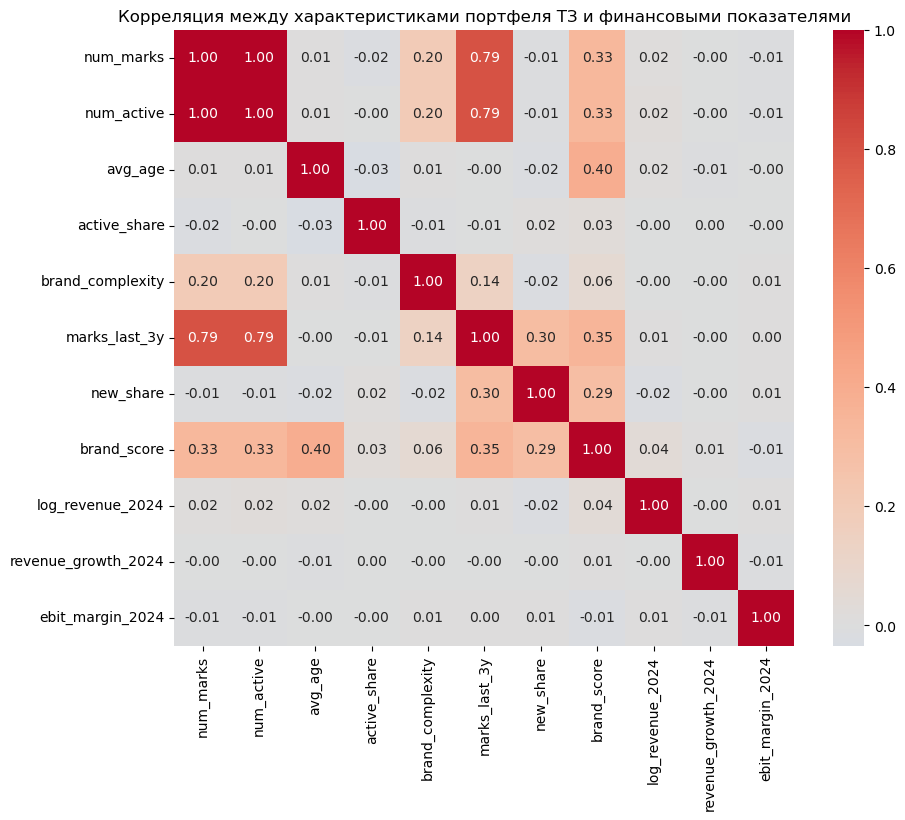

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Корреляция между характеристиками портфеля ТЗ и финансовыми показателями")
plt.show()

Для предварительной оценки взаимосвязей между характеристиками портфеля товарных знаков и экономическими показателями компаний была построена корреляционная матрица.

Анализ показал сильную положительную связь между количеством товарных знаков и числом действующих регистраций (коэффициент корреляции 0.999), что объясняется тем, что для большинства компаний практически все зарегистрированные знаки остаются активными.

Также наблюдается высокая корреляция между размером портфеля и количеством регистраций за последние годы (0.79), что свидетельствует о том, что компании с более крупными портфелями продолжают активно регистрировать новые товарные знаки.

При этом связь между характеристиками портфеля товарных знаков и финансовыми показателями компаний оказалась крайне слабой. Корреляции между показателями портфеля и логарифмом выручки, темпами роста и операционной маржой близки к нулю.

Это означает, что характеристики портфеля товарных знаков сами по себе не позволяют напрямую объяснить финансовые результаты компаний. Такой результат соответствует экономической логике: финансовые показатели формируются под влиянием множества факторов, тогда как товарные знаки являются лишь одним из элементов стратегии компании.

Простые группировки

In [41]:
df_merged["marks_group"] = pd.cut(
    df_merged["num_marks"],
    bins=[0, 1, 5, 100000],
    labels=["1", "2-5", "6+"]
)

df_merged["marks_group"].value_counts()

marks_group
1      7205
2-5    2877
6+      413
Name: count, dtype: int64

In [42]:
df_merged.groupby("marks_group")[
    ["log_revenue_2024", "revenue_growth_2024", "ebit_margin_2024"]
].median()

,log_revenue_2024,revenue_growth_2024,ebit_margin_2024
marks_group,,,
1,11.683579,0.199396,0.063969
2-5,11.718247,0.197232,0.068931
6+,11.757815,0.160707,0.071622


Для дополнительного анализа компании были сгруппированы по количеству товарных знаков. Было выделено три группы: компании с одним товарным знаком, компании с 2–5 знаками и компании с шестью и более регистрациями.

Распределение показывает, что подавляющее большинство компаний имеет минимальный портфель брендов: около 69% компаний владеют только одним товарным знаком. Компании с 2–5 знаками составляют около 27% выборки, тогда как компании с шестью и более регистрациями встречаются значительно реже.

Сравнение экономических показателей показывает, что медианная выручка постепенно увеличивается с ростом размера портфеля товарных знаков. Однако различия остаются относительно небольшими. Темпы роста выручки, напротив, оказываются несколько выше у компаний с минимальным портфелем, что может быть связано с эффектом низкой базы и более высокой динамикой малого бизнеса.

Операционная маржа демонстрирует слабую положительную связь с размером портфеля товарных знаков: компании с более развитым портфелем имеют несколько более высокую медианную маржу. Тем не менее различия остаются умеренными.

Регрессия на выручку

In [43]:
features = [
    "num_marks",
    "num_active",
    "avg_age",
    "active_share",
    "brand_complexity",
    "marks_last_3y",
    "new_share",
]

df_rev = df_merged[features + ["revenue_2024"]].copy()
df_rev = df_rev.dropna(subset=["revenue_2024"])
df_rev = df_rev[df_rev["revenue_2024"] > 0]

df_rev["log_revenue_2024"] = np.log(df_rev["revenue_2024"])

X = df_rev[features]
y = df_rev["log_revenue_2024"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(0.25853728031389134, 0.29877762157998045, -0.001042197100591391)

Регрессия на рост выручки 

In [44]:
df_growth = df_merged[features + ["revenue_growth_2024"]].copy()
df_growth = df_growth.replace([np.inf, -np.inf], np.nan)
df_growth = df_growth.dropna(subset=["revenue_growth_2024"])

X = df_growth[features]
y = df_growth["revenue_growth_2024"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_growth = LinearRegression()
model_growth.fit(X_train, y_train)

y_pred = model_growth.predict(X_test)

mae_growth = mean_absolute_error(y_test, y_pred)
rmse_growth = mean_squared_error(y_test, y_pred, squared=False)
r2_growth = r2_score(y_test, y_pred)

mae_growth, rmse_growth, r2_growth

(7.356074183148452, 70.09261105062524, 0.0004018360104123264)

Регрессия на EBIT margin

In [45]:
df_margin = df_merged[features + ["ebit_margin_2024"]].copy()
df_margin = df_margin.replace([np.inf, -np.inf], np.nan)
df_margin = df_margin.dropna(subset=["ebit_margin_2024"])

X = df_margin[features]
y = df_margin["ebit_margin_2024"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_margin = LinearRegression()
model_margin.fit(X_train, y_train)

y_pred = model_margin.predict(X_test)

mae_margin = mean_absolute_error(y_test, y_pred)
rmse_margin = mean_squared_error(y_test, y_pred, squared=False)
r2_margin = r2_score(y_test, y_pred)

mae_margin, rmse_margin, r2_margin

(0.20762419459771583, 1.4952117395648081, -0.0016522122756692514)

Линейная регрессия предполагает, что между переменными существует прямая линейная зависимость.
То есть модель пытается описать связь вида: $y = a_0 + a_1x_1 + a_2x_2 + ... + a_nx_n$, где $y$ — экономический показатель (например, выручка), а $x_i$ — характеристики портфеля товарных знаков.

Однако анализ данных показал, что между признаками товарных знаков и финансовыми показателями компаний нет выраженной линейной зависимости. Коэффициенты корреляции близки к нулю, а качество линейной модели оказалось низким.

Это связано с тем, что влияние товарных знаков на экономику компании носит косвенный и структурный характер, а не выражается в простой количественной зависимости.

Например, компании могут иметь одинаковое количество товарных знаков, но значительно различаться по масштабу бизнеса и финансовым показателям. Поэтому линейная модель не способна корректно описать такую структуру данных.

В первоначальной постановке исследования предполагалось проверить гипотезу о том, что характеристики портфеля товарных знаков могут использоваться для прогнозирования финансовых показателей компании. Иными словами, рассматривалась модель, в которой признаки интеллектуальной собственности выступают объясняющими переменными, а экономические показатели — зависимой переменной. Однако предварительный анализ данных показал, что между характеристиками портфеля товарных знаков и финансовыми показателями компаний отсутствует выраженная линейная зависимость. Коэффициенты корреляции между признаками портфеля и показателями выручки, темпов роста и рентабельности оказались близки к нулю, а качество линейной регрессионной модели оказалось низким.

Такой результат объясняется экономической природой рассматриваемых явлений. Финансовые показатели компании формируются под влиянием большого числа факторов: отраслевой структуры, размера бизнеса, рыночной конъюнктуры, организационной структуры и других параметров. Портфель товарных знаков является лишь одним из элементов стратегии компании и не может в изолированном виде объяснять финансовые результаты бизнеса. Поэтому использование характеристик товарных знаков для прямого прогнозирования выручки оказывается ограниченным.

В связи с этим постановка задачи была изменена. Вместо прогнозирования финансовых показателей по характеристикам товарных знаков рассматривается обратная зависимость: анализируется, какие экономические характеристики компаний связаны с активной стратегией управления товарными знаками. В этой постановке финансовые показатели выступают факторами, потенциально влияющими на инвестиции компании в развитие бренда, а характеристики портфеля товарных знаков рассматриваются как результат стратегических решений компании. Такой подход соответствует экономической логике: инвестиции в бренд, включая регистрацию товарных знаков, чаще всего являются следствием роста компании, расширения продуктовой линейки или выхода на новые рынки.

Для формализации стратегии брендинга вводится бинарный показатель активной работы с товарными знаками. Компания считается проводящей активную стратегию управления товарными знаками, если у нее есть новые регистрации ТЗ за последние годы и если в её портфеле присутствует более трёх зарегистрированных знаков. Данный порог выбран на основе анализа распределения числа товарных знаков в выборке. Большинство компаний имеет один зарегистрированный знак, что соответствует минимальной стратегии защиты бренда. Наличие двух или трёх знаков, как правило, связано с регистрацией вариантов одного и того же обозначения (например, словесного и графического варианта). В то же время портфель, содержащий более трёх товарных знаков, обычно свидетельствует о более системной работе с брендом, связанной с развитием линейки продуктов, регистрацией различных брендов или защитой бренда в нескольких категориях товаров и услуг. Таким образом, порог в три товарных знака позволяет отделить компании с минимальной регистрацией от компаний, реализующих более активную стратегию управления интеллектуальной собственностью.

В рамках новой постановки задачи используется модель логистической регрессии, позволяющая оценить влияние экономических характеристик компании на вероятность активной регистрации товарных знаков. Такой подход позволяет выявить, какие факторы — например, размер компании, темпы роста или уровень прибыльности — статистически связаны с более активным развитием бренда.

In [46]:
df_merged["active_brand_strategy"] = (
    (df_merged["num_marks"] > 3) &
    (df_merged["marks_last_3y"] > 0)
).astype(int)

In [47]:
df_merged["active_brand_strategy"].value_counts()

active_brand_strategy
0    9825
1     670
Name: count, dtype: int64

In [48]:
features = [
    "log_revenue_2024",
    "revenue_growth_2024",
    "ebit_margin_2024",
    "company_age_years",
    "employees_2024"
]

In [49]:
df_logit = df_merged[
    features + ["active_brand_strategy"]
].replace([np.inf, -np.inf], np.nan)

df_logit = df_logit.dropna()

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_logit[features]
y = df_logit["active_brand_strategy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_logit.fit(X_train, y_train)

y_pred = model_logit.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.56      0.70      1886
           1       0.07      0.55      0.13       119

    accuracy                           0.56      2005
   macro avg       0.51      0.56      0.42      2005
weighted avg       0.90      0.56      0.67      2005



In [51]:
import pandas as pd

coef_table = pd.DataFrame({
    "variable": features,
    "coef": model_logit.coef_[0]
})

coef_table

,variable,coef
0,log_revenue_2024,0.432331
1,revenue_growth_2024,-0.002918
2,ebit_margin_2024,-0.019701
3,company_age_years,0.013837
4,employees_2024,0.003438


Для проверки гипотезы о том, что экономические характеристики компаний связаны с активной стратегией регистрации товарных знаков, была построена модель логистической регрессии. Зависимой переменной выступает бинарный показатель активной стратегии брендинга, определяемый как наличие более трёх товарных знаков и регистраций за последние годы.

Результаты модели показывают, что вероятность активной регистрации товарных знаков положительно связана с масштабом компании. Наиболее значимый положительный коэффициент наблюдается для логарифма выручки, что означает, что более крупные компании существенно чаще реализуют стратегию активного развития бренда. Положительная связь также наблюдается для возраста компании и численности работников, что указывает на более активное использование товарных знаков зрелыми и более крупными организациями.

В то же время показатели темпов роста выручки и операционной маржи не демонстрируют выраженной связи с активностью регистрации товарных знаков. Это свидетельствует о том, что решения о развитии портфеля брендов зависят не только от текущих финансовых показателей, но и от более сложных стратегических факторов.

Экономический профиль кластеров

In [52]:
econ_profile = (
    df_merged
    .groupby("cluster")[[
        "log_revenue_2024",
        "revenue_growth_2024",
        "ebit_margin_2024"
    ]]
    .median()
    .round(3)
)

econ_profile

,log_revenue_2024,revenue_growth_2024,ebit_margin_2024
cluster,,,
-1,11.467,0.253,0.252
0,11.733,0.163,0.066
1,11.690,0.202,0.065
2,11.751,0.468,0.123


Для анализа экономических различий между выявленными типами компаний были рассчитаны медианные значения финансовых показателей для каждого кластера.

Сравнение показало, что компании с наиболее развитым портфелем товарных знаков (кластер 2) имеют более высокий масштаб бизнеса. Медианное значение логарифма выручки в этой группе является наибольшим среди основных кластеров.

Особенно заметные различия наблюдаются в темпах роста выручки. Компании кластера 2 демонстрируют значительно более высокие темпы роста (около 47%), тогда как в других кластерах этот показатель находится в диапазоне 16–20%. Это может свидетельствовать о том, что активная работа с портфелем товарных знаков связана с расширением бизнеса и развитием продуктовых линий.

Анализ операционной маржи показывает, что среди основной массы компаний наибольшие значения также характерны для кластера с развитой бренд-стратегией. Исключением является кластер −1, включающий небольшое число экстремальных правообладателей с очень крупными портфелями товарных знаков. Высокая маржа в этой группе может быть связана со специфической моделью бизнеса, например лицензионной деятельностью или холдинговой структурой.

В целом результаты свидетельствуют о том, что компании с более развитой стратегией управления товарными знаками в среднем имеют более высокий масштаб бизнеса и более высокие темпы роста.

Тест Краскела–Уоллиса

In [53]:
groups_revenue = [
    df_merged[df_merged["cluster"] == k]["log_revenue_2024"].dropna()
    for k in sorted(df_merged["cluster"].unique())
]
stat_rev, p_rev = kruskal(*groups_revenue)
stat_rev, p_rev

(18.72431319702564, 0.00031173100530749147)

In [54]:
groups_growth = [
    df_merged[df_merged["cluster"] == k]["revenue_growth_2024"].dropna()
    for k in sorted(df_merged["cluster"].unique())
]
stat_growth, p_growth = kruskal(*groups_growth)
stat_growth, p_growth

(11.3992227386209, 0.009751869770490815)

In [55]:
groups_margin = [
    df_merged[df_merged["cluster"] == k]["ebit_margin_2024"].dropna()
    for k in sorted(df_merged["cluster"].unique())
]
stat_margin, p_margin = kruskal(*groups_margin)
stat_margin, p_margin

(10.67193783208495, 0.013638774960490832)

Для проверки статистической значимости различий между кластерами был применён непараметрический тест Краскела–Уоллиса. Этот тест позволяет сравнивать распределения показателей между несколькими группами без предположения о нормальности распределения.

Результаты показали статистически значимые различия между кластерами по всем рассмотренным экономическим показателям. Для логарифма выручки значение p-value составило 0.00031, что свидетельствует о наличии значимых различий в масштабах бизнеса между типами компаний. Для темпов роста выручки p-value равно 0.0097, что также указывает на различия в динамике развития компаний различных кластеров. Для операционной маржи значение p-value составило 0.0136, что свидетельствует о наличии статистически значимых, хотя и менее выраженных различий между группами.

Таким образом, результаты теста подтверждают, что выделенные кластеры действительно различаются по экономическим характеристикам, а выявленные различия не являются случайными.

Тот же тест без кластера -1

In [56]:
df_test = df_merged[df_merged["cluster"] != -1].copy()

In [57]:
groups_revenue = [
    df_test[df_test["cluster"] == k]["log_revenue_2024"].dropna()
    for k in sorted(df_test["cluster"].unique())
]
stat_rev, p_rev = kruskal(*groups_revenue)
stat_rev, p_rev

(18.235530473746824, 0.00010969955613381963)

In [58]:
groups_growth = [
    df_test[df_test["cluster"] == k]["revenue_growth_2024"].dropna()
    for k in sorted(df_test["cluster"].unique())
]
stat_growth, p_growth = kruskal(*groups_growth)
stat_growth, p_growth

(11.396345927882965, 0.0033520842449332156)

In [59]:
groups_margin = [
    df_test[df_test["cluster"] == k]["ebit_margin_2024"].dropna()
    for k in sorted(df_test["cluster"].unique())
]
stat_margin, p_margin = kruskal(*groups_margin)
stat_margin, p_margin

(4.162236128235236, 0.12479061026761433)

Поскольку один из кластеров включал небольшое число экстремальных правообладателей с очень крупными портфелями товарных знаков, анализ был дополнительно проведён без учёта этого кластера.

Результаты теста Краскела–Уоллиса показали, что различия в медианной выручке между кластерами остаются статистически значимыми (p = 0.00011). Аналогично сохраняются значимые различия в темпах роста выручки (p = 0.00335).

При этом различия в операционной марже между основными кластерами оказываются статистически незначимыми (p = 0.125). Это означает, что после исключения экстремальных правообладателей стратегия управления товарными знаками не демонстрирует устойчивой связи с уровнем операционной рентабельности компаний.

Таким образом, результаты анализа показывают, что различия между стратегиями управления товарными знаками связаны прежде всего с масштабом и динамикой развития бизнеса, но не являются самостоятельным фактором операционной эффективности.

Сохранение датасетов для сервиса и дашборда

In [125]:
company_df_for_service = df_ml.copy()
company_df_for_service.to_csv("companies_dataset.csv", index=False)

In [62]:
df_merged.to_csv("companies_merged_dataset.csv", index=False)

In [63]:
df_merged.shape

(10495, 46)

In [64]:
#получаем уникальные ИНН из df_merged
inn_set = set(df_merged['inn'])

#фильтруем df по этим ИНН
filtered = df[df['inn'].isin(inn_set)]

#берем колонку с номерами регистрации
registration_numbers = filtered['reg_number']

#сохраняем в txt
registration_numbers.to_csv('result.txt', index=False, header=False)

In [65]:
registration_numbers.shape

(19949,)

In [68]:
df_merged.head()

,inn,owner,num_marks,num_active,avg_age,active_share,has_color,has_3d,has_sound,has_light,...,debt_total_2024,debt_long_2024,debt_short_2024,liab_long_2024,liab_short_2024,revenue_growth_2024,ebit_margin_2024,log_revenue_2024,marks_group,active_brand_strategy
0,0104011021,"общество с ограниченной ответственностью ""лагу...",1,1,1.631759,1.0,0,0,0,0,...,12054.0,6293.0,3657.0,6293.0,5761.0,0.166568,0.504534,11.320408,1,0
1,0104013195,"общество с ограниченной ответственностью ""диал...",1,1,6.078029,1.0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,0.009658,0.075712,11.351571,1,0
2,0105039171,общество с ограниченной ответственностью «гипп...,1,1,3.359343,1.0,0,0,0,0,...,14579.0,846.0,NaN,10071.0,4508.0,0.419965,0.460859,11.257065,1,0
3,0105045383,"общество с ограниченной ответственностью ""мета...",2,2,3.103354,1.0,0,0,0,0,...,22927.0,6874.0,183.0,6874.0,16053.0,0.113107,0.057907,12.141395,2-5,0
4,0105050009,общество с ограниченной ответственностью «майк...,5,4,1.975633,0.8,0,0,0,0,...,43093.0,NaN,7915.0,NaN,43093.0,0.862180,0.146246,11.464481,2-5,1


In [77]:
df_merged.columns

Index(['inn', 'owner', 'num_marks', 'num_active', 'avg_age', 'active_share',
       'has_color', 'has_3d', 'has_sound', 'has_light', 'has_positional',
       'has_changing', 'first_reg_date', 'last_reg_date', 'marks_last_3y',
       'new_share', 'brand_complexity', 'brand_score', 'cluster', 'pca_x',
       'pca_y', 'company_name', 'company_reg_date', 'company_age_years',
       'region', 'industry', 'opf', 'company_size', 'employees_2024',
       'revenue_2023', 'revenue_2024', 'ebit_2024', 'net_profit_2024',
       'assets_2024', 'equity_reserves_2024', 'equity_2024', 'debt_total_2024',
       'debt_long_2024', 'debt_short_2024', 'liab_long_2024',
       'liab_short_2024', 'revenue_growth_2024', 'ebit_margin_2024',
       'log_revenue_2024', 'marks_group', 'active_brand_strategy'],
      dtype='object')

In [69]:
#приводим к одному типу
df['inn'] = df['inn'].astype(str)
df_merged['inn'] = df_merged['inn'].astype(str)

#фильтруем только нужные ИНН
filtered = df[df['inn'].isin(df_merged['inn'])]

#группируем: для каждого ИНН собираем список номеров
grouped = filtered.groupby('inn')['reg_number'].apply(list)

#сохраняем в txt
with open('result.txt', 'w') as f:
    for inn, numbers in grouped.items():
        f.write(f"{inn}: {', '.join(map(str, numbers))}\n")